<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB


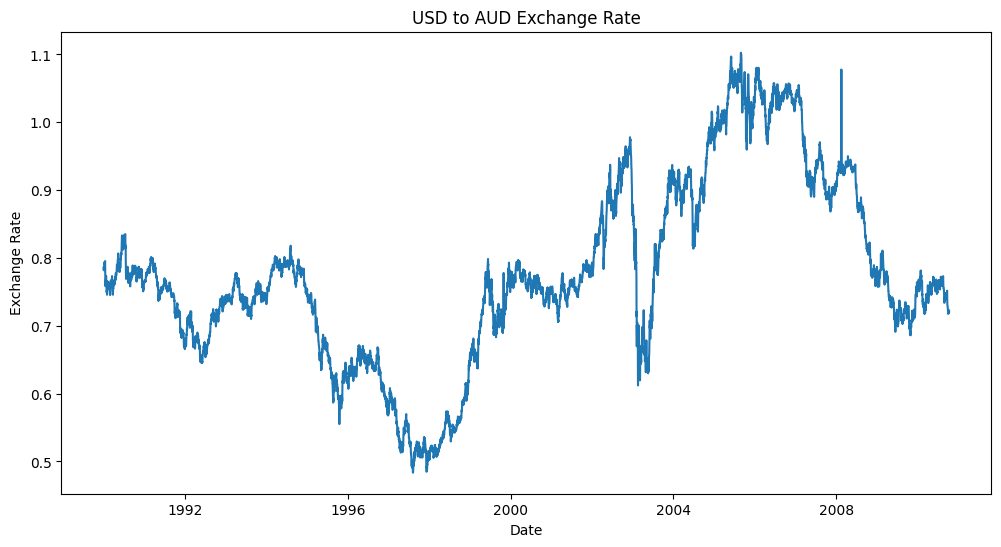

/tmp/ipykernel_4696/1018356615.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')   # Forward fill


ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477


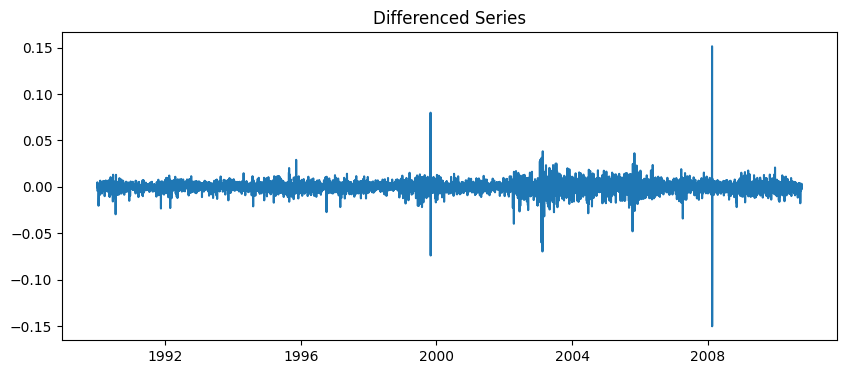

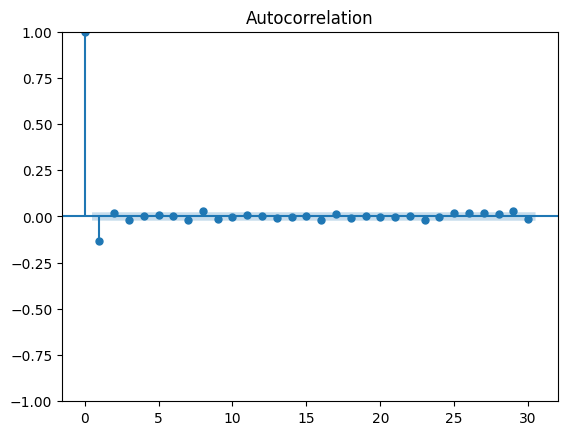

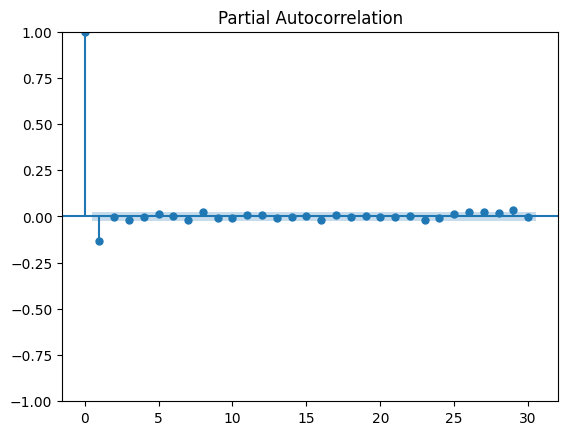

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Wed, 22 Apr 2026   AIC                         -45432.092
Time:                        03:09:56   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

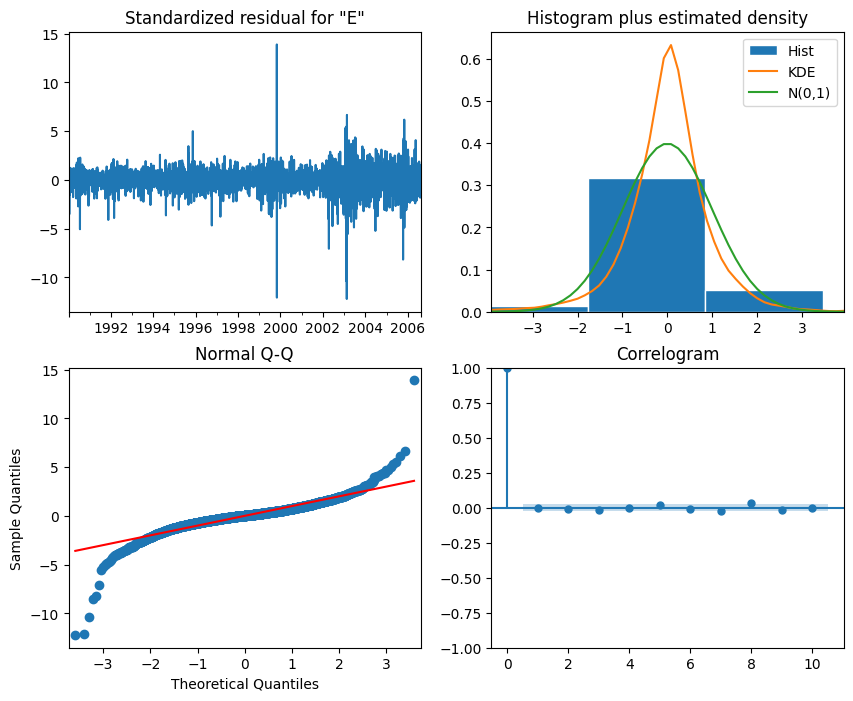

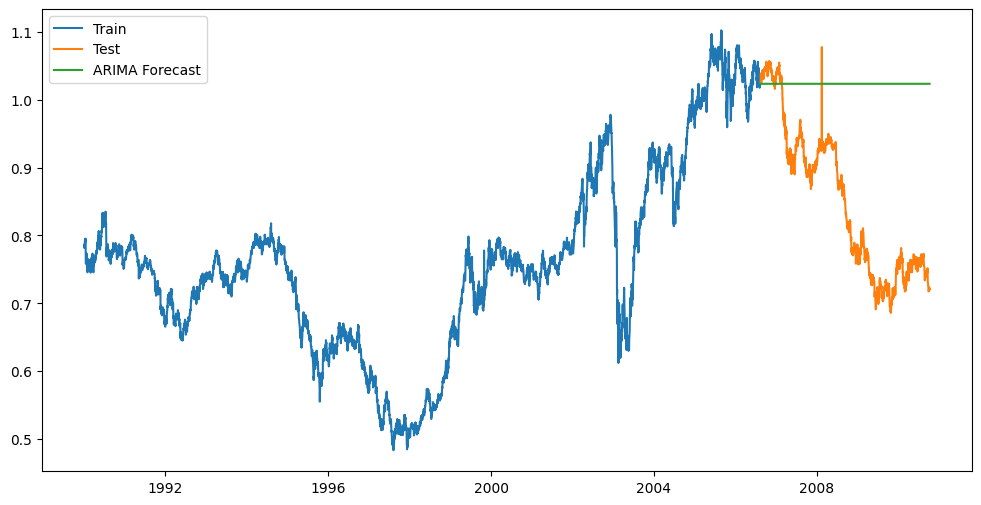

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


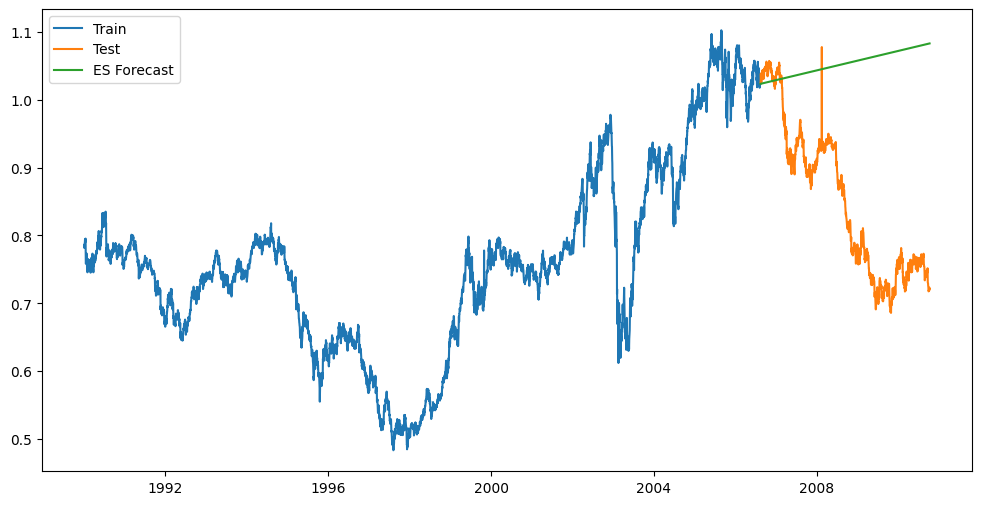

ARIMA -> MAE: 0.17770970449121345 RMSE: 0.2054366965966928 MAPE: 22.797966173811552
ExpSmooth -> MAE: 0.20659619114093827 RMSE: 0.23910443161792286 MAPE: 26.50866379878783


In [1]:
import numpy as np
import pandas as pd

df=pd.read_csv(r"/content/exchange_rate.csv")

df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df.set_index('date', inplace=True)

df.info()

df.describe()

df.isnull().sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df.iloc[:,0])
plt.title("USD to AUD Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.show()

df = df.fillna(method='ffill')   # Forward fill

from statsmodels.tsa.stattools import adfuller

result = adfuller(df.iloc[:,0])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ts = df.iloc[:,0]
ts_diff = ts.diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(ts_diff)
plt.title("Differenced Series")
plt.show()

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_diff, lags=30)
plt.show()

plot_pacf(ts_diff, lags=30)
plt.show()

train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train, order=(1,1,1))
model_arima_fit = model_arima.fit()
print(model_arima_fit.summary())

model_arima_fit.plot_diagnostics(figsize=(10,8))
plt.show()
forecast_arima = model_arima_fit.forecast(steps=len(test))

plt.figure(figsize=(12,6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast')
plt.legend()
plt.show()

from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(train,
                                trend='add',
                                seasonal=None)

model_es_fit = model_es.fit()
forecast_es = model_es_fit.forecast(len(test))

plt.figure(figsize=(12,6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast_es, label='ES Forecast')
plt.legend()
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted)/actual)) * 100
    return mae, rmse, mape

mae_a, rmse_a, mape_a = evaluate(test, forecast_arima)
mae_e, rmse_e, mape_e = evaluate(test, forecast_es)

print("ARIMA -> MAE:", mae_a, "RMSE:", rmse_a, "MAPE:", mape_a)
print("ExpSmooth -> MAE:", mae_e, "RMSE:", rmse_e, "MAPE:", mape_e)


In [ ]:
#Exchange rate shows non-stationary behavior.
#Differencing was required for ARIMA.
#ARIMA captured short-term fluctuations better.
#Exponential smoothing performed well for trend.
#Based on error metrics, (choose lower RMSE model) performed better.